<a href="https://colab.research.google.com/github/joebathelt/AUC_CogPsy/blob/main/week10_mental_rotation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mental Rotation

### Background
This experiment is based on a classic study by Shepard and Metzler (1971). In this study, participants were required to determine whether two 3D block shapes were identical. The main difficulty was caused by rotating one of the two shapes, which makes the comparison much more challenging. The crucial manipulation was the **rotation angle**, which allowed an examination of the effect of rotation angle on response times (RTs).

Shepard and Metzler found a linear increase in RTs as a function of rotation angle. This has been interpreted as evidence that participants *mentally rotated* one of the objects so that both could be imagined from the same angle. The linear relationship was assumed to be the consequence of a constant mental rotation speed. These results seem to fit the view that imagery is a visuospatial process — that is, a mental image relies on the same or similar mechanisms as visual perception (Kosslyn's view, as discussed in the lecture).

**References**:
- Shepard, R. N., & Metzler, J. (1971). Mental rotation of three-dimensional objects. *Science*, 171(3972), 701–703. DOI: 10.1126/science.171.3972.701
- Optional: Kosslyn, S. M. (1994). *Image and Brain: The Resolution of the Imagery Debate*. MIT Press.


In [15]:
# This cell loads the data. You don't need to change it or understand it. Just run the cell.
import pandas as pd

file_id = '1EnA1m-igkc4TpS7UMnoRQwR-YfVrvcUi'
url = f'https://docs.google.com/uc?export=download&id={file_id}'
df = pd.read_csv(url)


In [16]:
df


,username,correct,different,0_same,20_same,40_same,60_same,80_same,100_same,120_same
0,A01,0.742857,735.400000,219.8,234.6,1695.0,1490.0,345.2,407.6,526.8
1,A02,0.957143,24315.428571,421.4,270.0,365.4,329.2,11334.6,395.0,856.8
2,A03,0.742857,1160.971429,1114.6,938.2,907.6,701.0,953.8,1376.6,708.0
3,A04,0.657143,1463.371429,1660.4,1822.2,2262.2,1727.8,1177.4,2699.4,1852.8
4,A05,0.842857,776.371429,1815.4,757.0,767.2,486.6,880.8,1485.8,1815.6
5,A06,0.842857,692.114286,499.0,602.2,519.6,659.2,1603.0,561.0,578.4
6,A07,0.914286,600.028571,1029.6,499.8,528.0,549.8,1031.8,527.0,711.8
7,A09,0.628571,2402.085714,2510.4,2643.2,995.2,2483.0,1506.6,3343.2,693.0
8,A10,0.542857,1219.857143,921.6,1703.2,2352.2,702.8,1165.0,1345.0,2786.2
9,A11,0.900000,377.085714,235.8,667.4,383.0,664.8,406.8,444.2,1121.8


**Note**: The `correct` column shows overall accuracy. The `different` column contains RTs for trials where the two shapes were different. The columns `0_same` through `120_same` contain RTs for 'same' trials at each rotation angle (0°–120°).


<div style="background-color: #d1ecf1; border-left: 5px solid #0dcaf0; padding: 10px; margin: 10px 0;">
<strong>Insight</strong>: There is only one column for 'different' (RTs for when the 3D shapes were different), but there are seven columns for 'same', organised by rotation angle (0°–120°). Why is there only one column for 'different'?
</div>


### Data Cleaning
Before analysing the data, we should remove any participants with incomplete data or with an accuracy below 70%.


In [17]:
# Remove participants with accuracy below 70%
df_clean = df[df['correct'] >= 0.70].copy()

print(f'Participants before cleaning: {len(df)}')
print(f'Participants after cleaning: {len(df_clean)}')


Participants before cleaning: 32
Participants after cleaning: 26


<div style="background-color: #d1ecf1; border-left: 5px solid #0dcaf0; padding: 10px; margin: 10px 0;">
<strong>Insight</strong>: What are the two main reasons for removing participants with low accuracy?
</div>


### Effect of Rotation Angle on Response Time
Now let's plot the average RT for 'same' trials at each rotation angle.


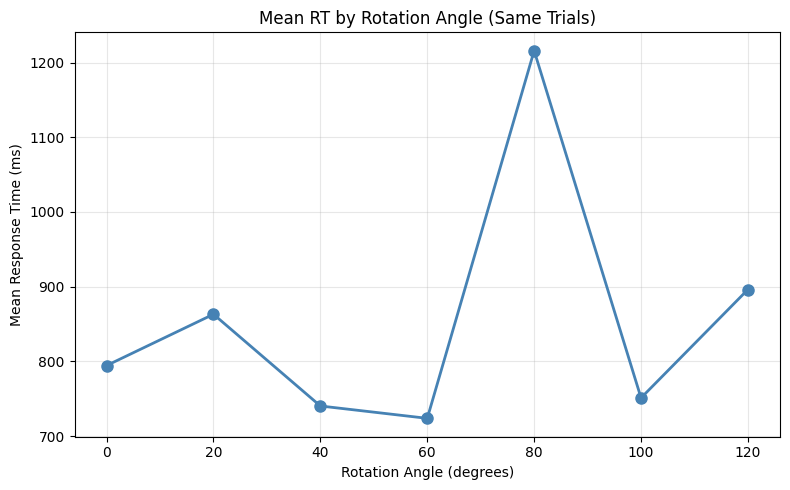

In [18]:
import matplotlib.pyplot as plt

# Define the rotation angles and corresponding column names
angles = [0, 20, 40, 60, 80, 100, 120]
same_columns = ['0_same', '20_same', '40_same', '60_same', '80_same', '100_same', '120_same']

# Calculate the mean RT for each rotation angle
mean_rts = [df_clean[col].mean() for col in same_columns]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(angles, mean_rts, 'o-', color='steelblue', linewidth=2, markersize=8)
plt.xlabel('Rotation Angle (degrees)')
plt.ylabel('Mean Response Time (ms)')
plt.title('Mean RT by Rotation Angle (Same Trials)')
plt.xticks(angles)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


<div style="background-color: #d1ecf1; border-left: 5px solid #0dcaf0; padding: 10px; margin: 10px 0;">
<strong>Insight</strong>: Does the increase in RT with rotation angle look linear, exponential, or logarithmic to you?
</div>


### Difference Scores
To investigate whether the increase in RT is linearly related to the rotation angle, we first need to calculate difference scores between successive rotation angles.


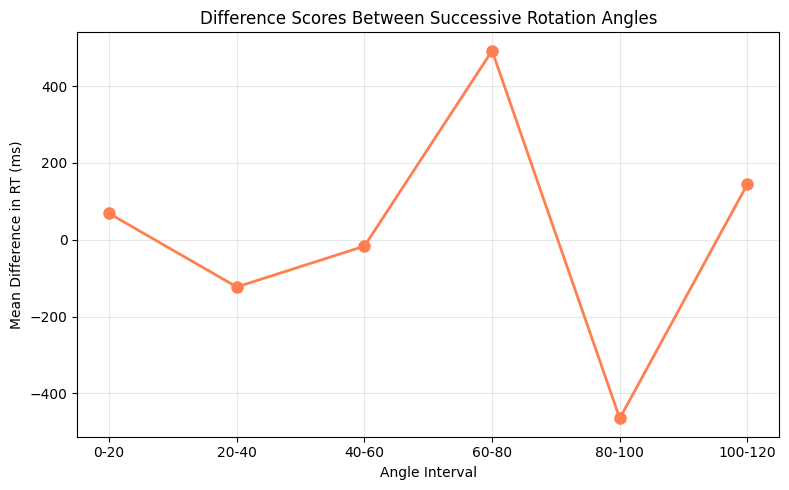

In [19]:
# Calculate difference scores between successive rotation angles
df_clean['diff_0_20'] = df_clean['20_same'] - df_clean['0_same']
df_clean['diff_20_40'] = df_clean['40_same'] - df_clean['20_same']
df_clean['diff_40_60'] = df_clean['60_same'] - df_clean['40_same']
df_clean['diff_60_80'] = df_clean['80_same'] - df_clean['60_same']
df_clean['diff_80_100'] = df_clean['100_same'] - df_clean['80_same']
df_clean['diff_100_120'] = df_clean['120_same'] - df_clean['100_same']

diff_columns = ['diff_0_20', 'diff_20_40', 'diff_40_60', 'diff_60_80', 'diff_80_100', 'diff_100_120']
mean_diffs = [df_clean[col].mean() for col in diff_columns]

# Plot
diff_labels = ['0-20', '20-40', '40-60', '60-80', '80-100', '100-120']
plt.figure(figsize=(8, 5))
plt.plot(diff_labels, mean_diffs, 'o-', color='coral', linewidth=2, markersize=8)
plt.xlabel('Angle Interval')
plt.ylabel('Mean Difference in RT (ms)')
plt.title('Difference Scores Between Successive Rotation Angles')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


<div style="background-color: #d1ecf1; border-left: 5px solid #0dcaf0; padding: 10px; margin: 10px 0;">
<strong>Insight</strong>: If the relationship between RT and rotation angle is linear, the difference scores should be roughly constant. If the relationship is non-linear (i.e. exponential or logarithmic), then the difference scores should either increase or decrease as the rotation angle increases. Why is that?
</div>


### Testing Linearity
To see whether the difference scores increase or decrease, we can fit a line through each participant's difference scores using linear regression and then test whether the slopes differ from zero.


In [20]:
import numpy as np
from scipy.stats import ttest_1samp

# For each participant, fit a line through the difference scores
x = np.arange(len(diff_columns))  # 0, 1, 2, 3, 4, 5

slopes = []
for _, row in df_clean.iterrows():
    diffs = [row[col] for col in diff_columns]
    slope, intercept = np.polyfit(x, diffs, 1)
    slopes.append(slope)

df_clean['slope'] = slopes

print(f'Mean slope: {np.mean(slopes):.4f}')
print(f'SD of slopes: {np.std(slopes, ddof=1):.4f}')


Mean slope: -3.8560
SD of slopes: 179.1005


<div style="background-color: #d1ecf1; border-left: 5px solid #0dcaf0; padding: 10px; margin: 10px 0;">
<strong>Insight</strong>: The slope is 0 if the difference scores are flat (→ linear RT increase), above 0 if the difference scores go up (→ exponential), and below 0 if they go down (→ logarithmic). What does a flat line of difference scores mean in terms of mental rotation speed?
</div>


Now let's test whether the slopes are significantly different from zero using a one-sample t-test.


In [21]:
# Perform a one-sample t-test on the slopes against 0
t_statistic, p_value = ttest_1samp(df_clean['slope'], 0)
degrees_of_freedom = len(df_clean) - 1

print(f't-statistic: {t_statistic:.4f}')
print(f'degrees of freedom: {degrees_of_freedom}')
print(f'p-value: {p_value:.4f}')


t-statistic: -0.1098
degrees of freedom: 25
p-value: 0.9135


<div style="background-color: #d1ecf1; border-left: 5px solid #0dcaf0; padding: 10px; margin: 10px 0;">
<strong>Insight</strong>: Is the relationship between RT and rotation angle linear?
</div>


### Bayesian Analysis in JASP
To get stronger evidence about whether the relationship is linear, we can use a Bayesian one-sample t-test. Download the file below and open it in JASP. Perform a Bayesian one-sample t-test on the variable `slope`, with 0 as the test value.


In [22]:
from google.colab import files

# Download the file to your computer
df_clean[['username', 'slope']].to_csv('mental-rotation_JASP.csv', index=False)
files.download('mental-rotation_JASP.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Bonus Questions: Experimental Design
1. Is the result we find the same as the result by Shepard and Metzler (1971)? If not, how can you explain the difference?
2. What does your answer to the linearity question mean for the debate between Kosslyn and Pylyshyn?
<div style="background-color: #d1ecf1; border-left: 5px solid #0dcaf0; padding: 10px; margin: 10px 0;">
<strong>Insight</strong>: Can you think of any other analyses that might have been interesting?
</div>
